# SDE-Net paper-faithful no-PV-lag — evento 28–29 giugno 2019

Analisi post-hoc del modello già addestrato. Il notebook **non rilancia il training** e usa tutte le predizioni disponibili, senza campionamento.

La diagnostica mostra la risposta temporale del modello e confronta separatamente 28 giugno, 29 giugno e condizioni normali nelle cinque fasce di produzione.

In [1]:
from pathlib import Path
import importlib
import sys

from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'physiq_pv').is_dir():
    raise FileNotFoundError('Avviare il notebook dalla root del repository o da notebooks/.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import physiq_pv.reporting.posthoc_outputs as posthoc_outputs
import physiq_pv.experiments.sde_pipeline as pipe

importlib.reload(posthoc_outputs)
pipe = importlib.reload(pipe)

RUN_NAME = 'pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1'
out_dir = ROOT / 'outputs' / RUN_NAME
predictions_path = out_dir / 'predictions.csv'
reference_peak_path = out_dir / 'reference_production_peaks.csv'

for required in (predictions_path, reference_peak_path):
    if not required.is_file():
        raise FileNotFoundError(required)

print('Run SDE-Net:', out_dir)
print('Predizioni:', predictions_path)

Run SDE-Net: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1
Predizioni: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/predictions.csv


## Risposta temporale del modello

La diagnostica usa tutte le 1.149 località. Le aree rosse identificano le ore classificate come evento regionale raro dal protocollo stagionale P97.5.

Righe usate (nessun campionamento): 55,152
Soglia regionale stagionale: 0.3532201914708445


,scope,count,locations,timestamps,mae,rmse,picp,mpiw,rare_timestamp_count,mean_y_std,mean_epistemic_std,mean_aleatoric_std
0,all_event_hours,55152,1149,48,19.919950,42.184878,0.975395,130.948941,48,33.405926,0.095169,33.405661
1,daytime,33789,1149,30,32.468318,53.894147,0.959839,211.887513,30,54.053881,0.155303,54.053449
2,regional_rare_hours,55152,1149,48,19.919950,42.184878,0.975395,130.948941,48,33.405926,0.095169,33.405661


,timestamp,n_rows,mean_y_true,mean_y_pred,mean_lower_pi,mean_upper_pi,mae,picp,mpiw,is_rare,mean_y_std,mean_event_score,mean_solar,mean_epistemic_std,mean_aleatoric_std,rmse,regional_anomaly_fraction
0,2019-06-28 00:10:00,1149,0.000000,1.445553e-08,-1.396596,1.396596,1.445553e-08,1.000000,2.793192,True,0.712562,1.680424,0.000000,8.721281e-12,0.712562,1.492606e-08,0.593560
1,2019-06-28 01:10:00,1149,0.000000,1.448463e-08,-1.396596,1.396596,1.448463e-08,1.000000,2.793192,True,0.712562,1.613897,0.000000,7.980690e-12,0.712562,1.487660e-08,0.570061
2,2019-06-28 02:10:00,1149,0.000000,3.999912e-08,-1.396596,1.396596,3.999912e-08,1.000000,2.793192,True,0.712562,1.581865,0.000000,1.900380e-11,0.712562,4.077211e-08,0.558747
3,2019-06-28 03:10:00,1149,0.000000,4.266630e-06,-1.396592,1.396600,4.266630e-06,1.000000,2.793192,True,0.712562,1.525194,0.000000,2.077286e-09,0.712562,4.844288e-06,0.538729
4,2019-06-28 04:10:00,1149,5.222602,3.230823e+00,-0.711582,7.173234,1.997852e+00,0.906005,7.884816,True,2.011470,1.448811,17.052776,2.376244e-03,2.011468,2.282877e+00,0.511749
5,2019-06-28 05:10:00,1149,88.568895,8.763493e+01,44.873935,130.397121,2.141540e+01,0.956484,85.523186,True,21.817460,1.434027,138.796345,1.785107e-01,21.816671,2.419064e+01,0.506527
6,2019-06-28 06:10:00,1149,235.913855,2.314977e+02,148.721748,314.273833,2.722510e+01,0.965187,165.552086,True,42.233432,1.505482,318.024369,1.050874e-01,42.233285,4.580082e+01,0.531767
7,2019-06-28 07:10:00,1149,383.978224,3.715943e+02,271.080420,472.108233,2.478587e+01,1.000000,201.027814,True,51.283536,1.596649,509.548303,8.589020e-02,51.283448,4.887663e+01,0.563969
8,2019-06-28 08:10:00,1149,508.987267,5.049213e+02,434.281026,575.561554,1.558651e+01,0.999130,141.280527,True,36.041576,1.697672,685.027850,1.712779e-01,36.041053,3.640101e+01,0.599652
9,2019-06-28 09:10:00,1149,605.419644,5.992772e+02,546.840518,651.713855,1.474939e+01,0.992167,104.873337,True,26.753877,1.806086,823.543081,1.272714e-01,26.753532,2.361725e+01,0.637946


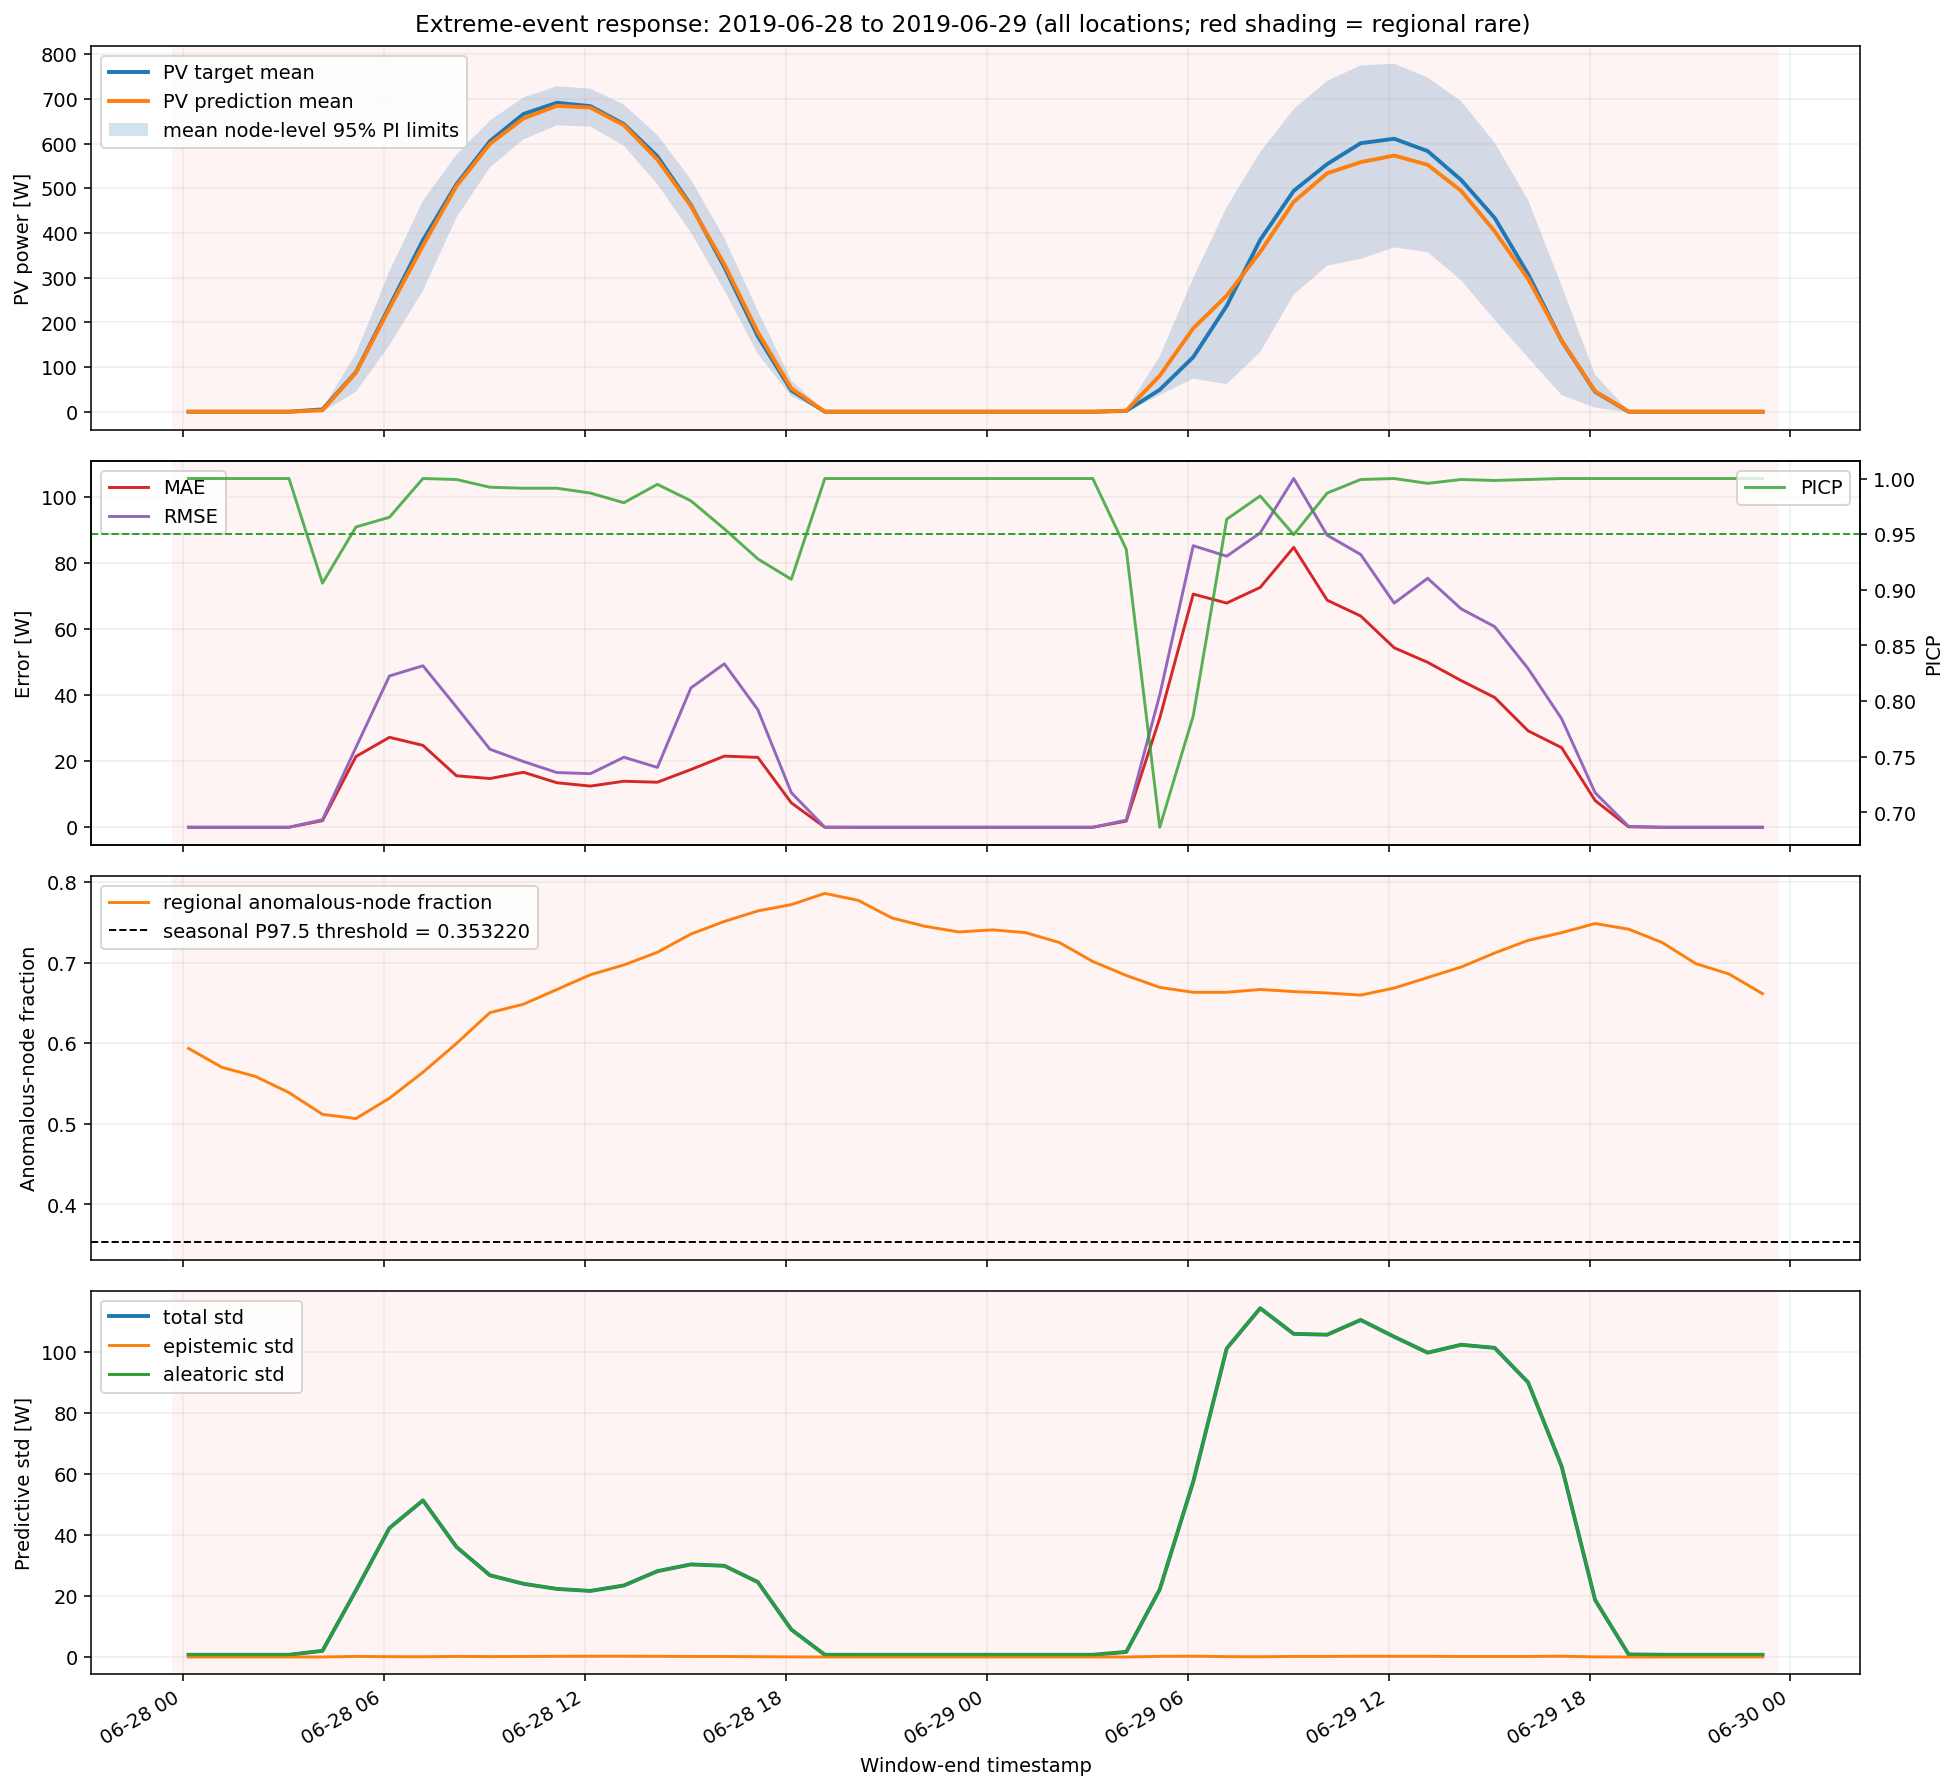

CSV orario: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/extreme_event_20190628_20190629_hourly.csv
CSV riepilogo: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/extreme_event_20190628_20190629_summary.csv


In [2]:
june_event = pipe.build_extreme_event_diagnostic(
    out_dir,
    start='2019-06-28',
    end='2019-06-30',  # estremo escluso: include tutto il 28 e 29 giugno
    figure_subdir='june_extreme_event',
)
print(f"Righe usate (nessun campionamento): {june_event['rows_used']:,}")
print('Soglia regionale stagionale:', june_event['regional_threshold'])
display(june_event['summary'])
display(june_event['hourly'])
display(Image(filename=str(june_event['figure_path'])))
print('CSV orario:', june_event['hourly_path'])
print('CSV riepilogo:', june_event['summary_path'])

## Normale 2019 vs 28 giugno vs 29 giugno

Boxplot, istogrammi e metriche usano tutte le predizioni diurne valide e sono separati nelle fasce 0–20%, 20–40%, 40–60%, 60–80% e 80–100% della potenza di riferimento.

,bin,category,count,mae,rmse,mpiw,nmpil,picp,clc
0,daytime_0_20_pct,normal_2019,1853036,37.619493,64.466691,174.616821,0.195789,0.954631,0.383587
1,daytime_0_20_pct,2019-06-28,3870,23.217063,49.420462,68.869589,0.077220,0.886563,0.213893
2,daytime_0_20_pct,2019-06-29,4104,44.514484,70.198424,147.815769,0.165739,0.826998,0.667152
3,daytime_20_40_pct,normal_2019,826945,46.898077,68.726285,265.896231,0.298137,0.947657,0.602628
4,daytime_20_40_pct,2019-06-28,1966,13.579835,22.422831,119.843529,0.134375,0.996948,0.222442
5,daytime_20_40_pct,2019-06-29,2379,45.619543,69.851633,344.107172,0.385831,0.971417,0.704021
6,daytime_40_60_pct,normal_2019,712727,46.886583,70.587735,281.364087,0.315480,0.961600,0.599686
7,daytime_40_60_pct,2019-06-28,2200,15.554337,28.300671,145.383311,0.163011,0.995000,0.271736
8,daytime_40_60_pct,2019-06-29,2783,48.510593,67.094460,453.192964,0.508144,0.986705,0.873334
9,daytime_60_80_pct,normal_2019,640750,46.397372,77.305879,272.423647,0.305456,0.968471,0.564128


CSV metriche: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/extreme_event_comparison_metrics.csv
Grafici creati: 20


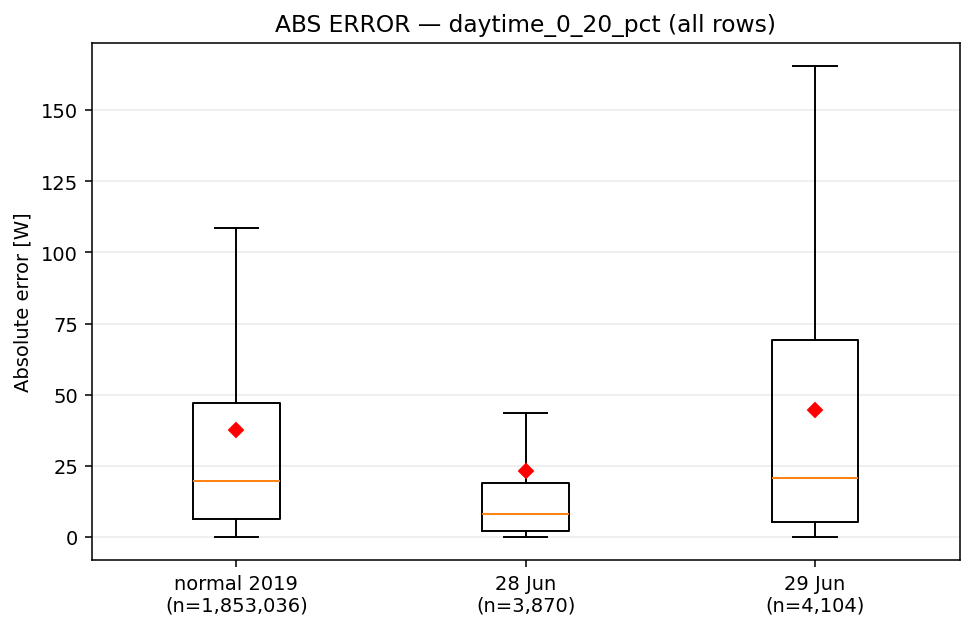

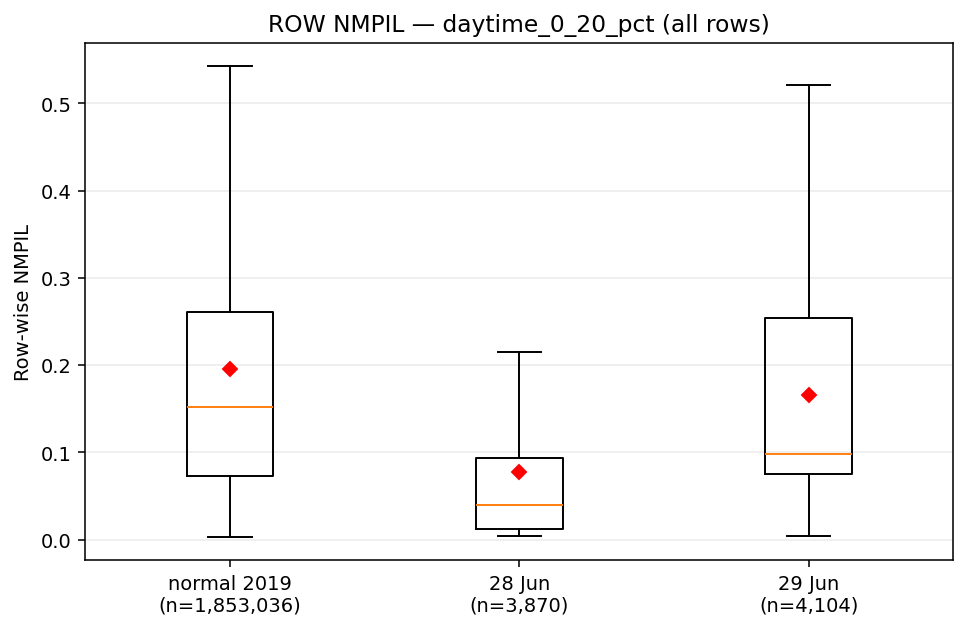

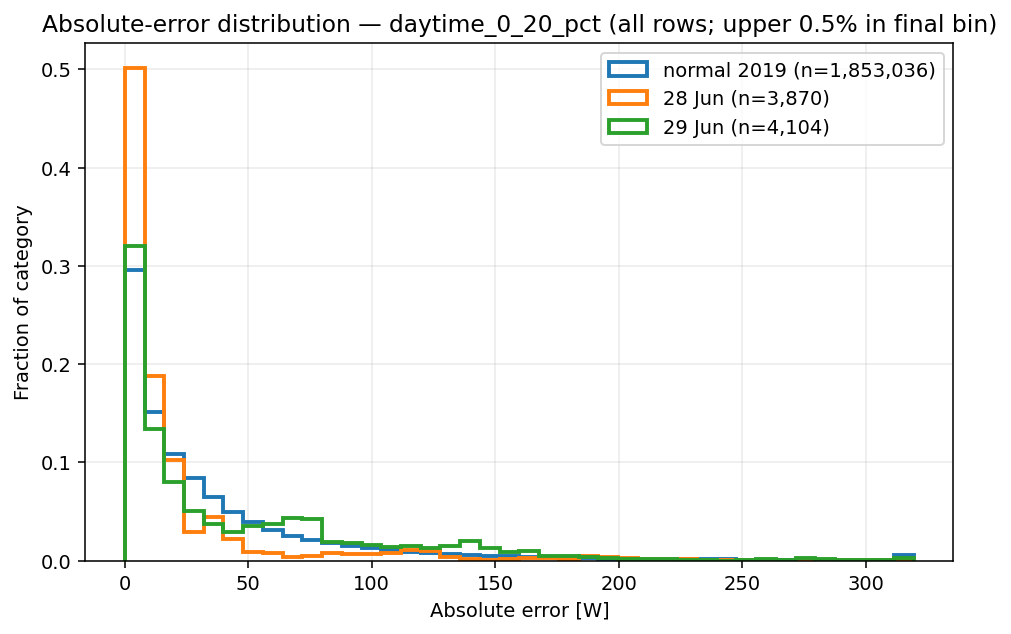

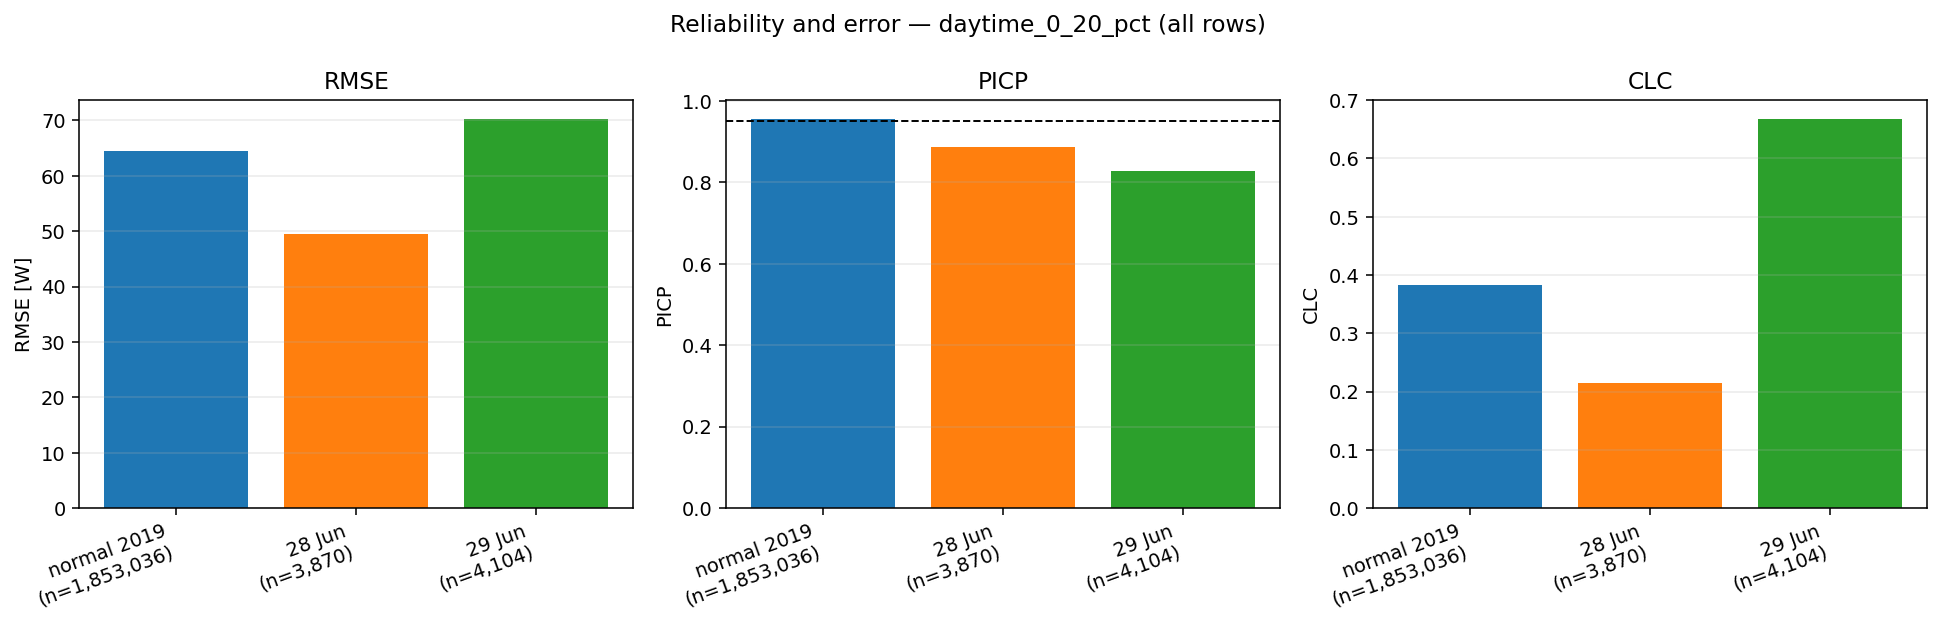

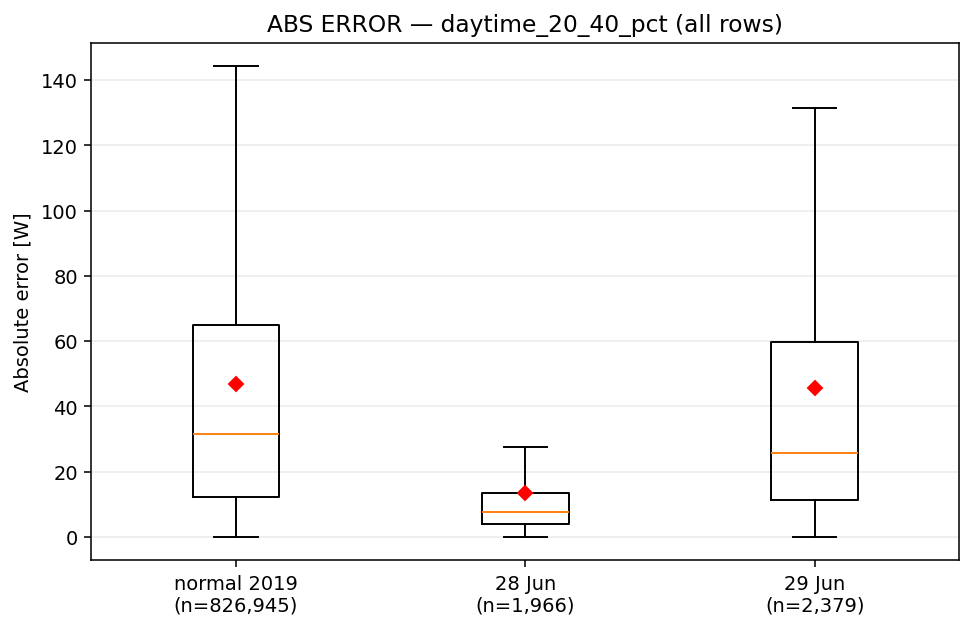

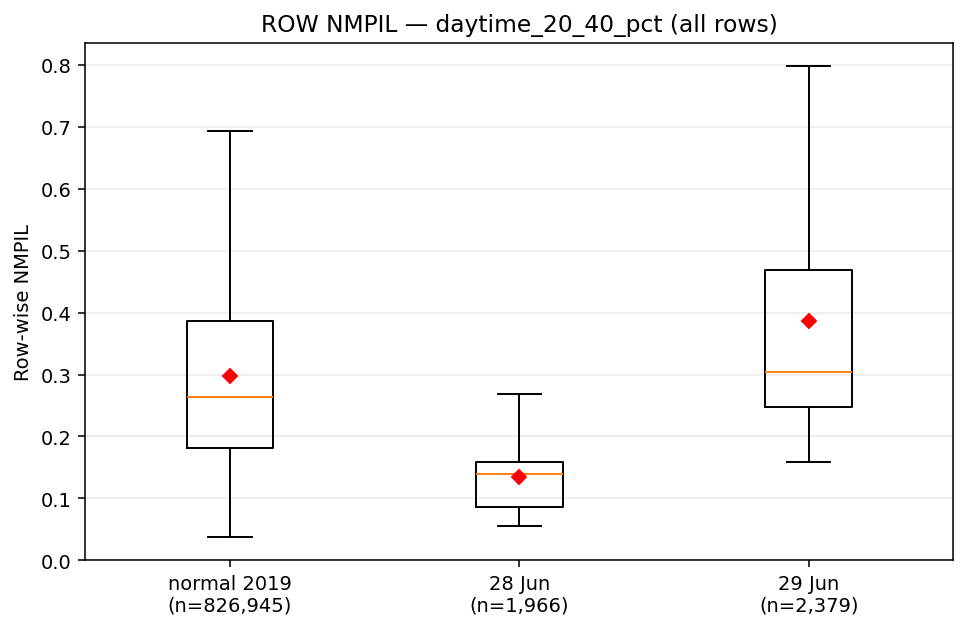

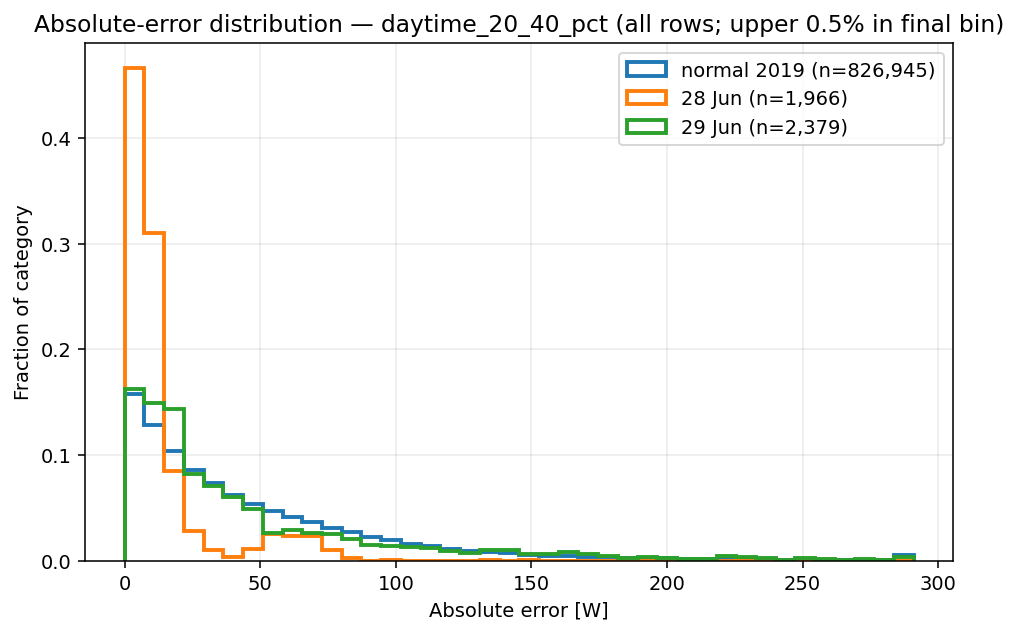

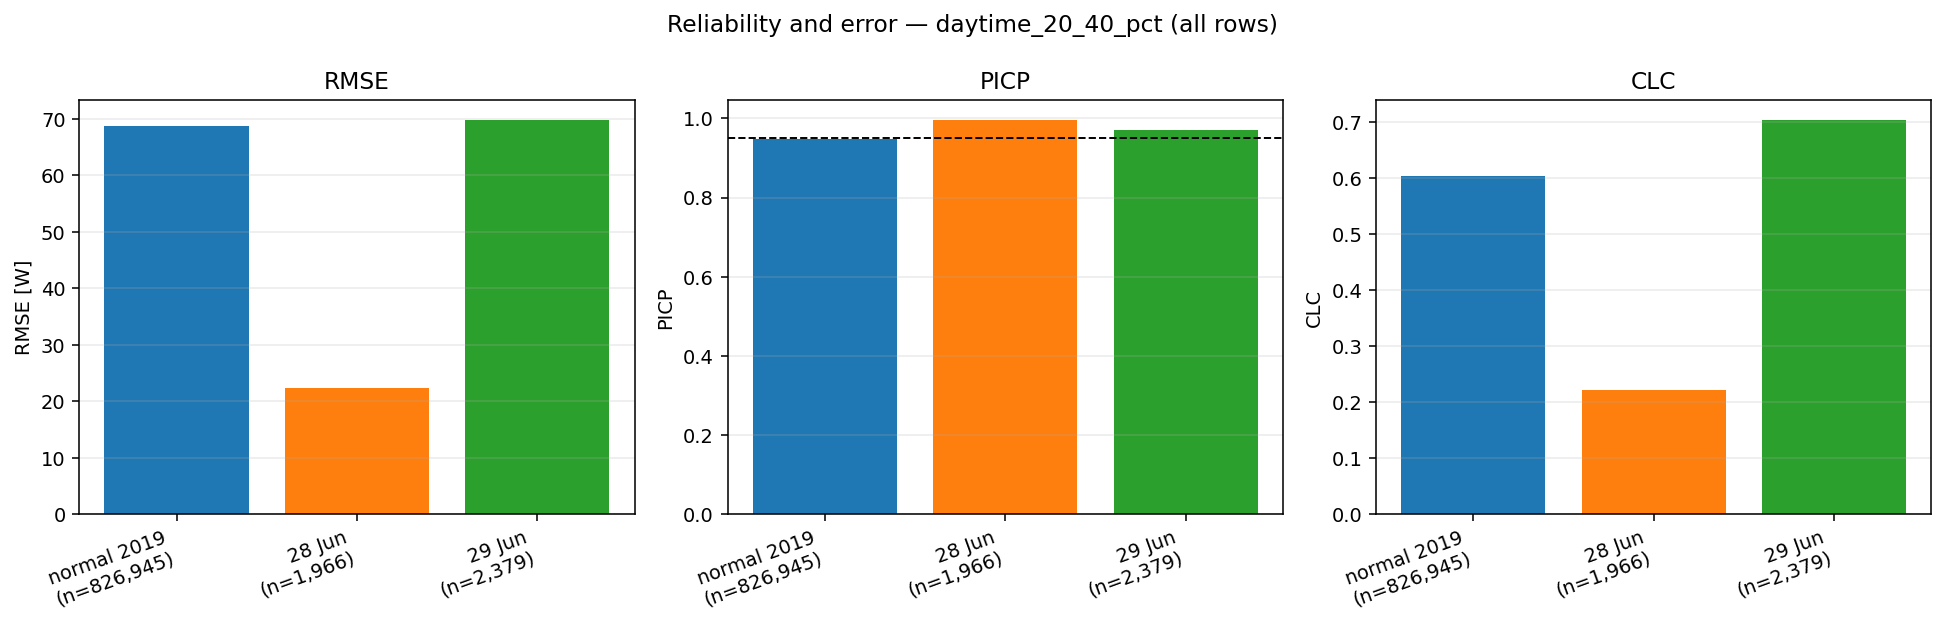

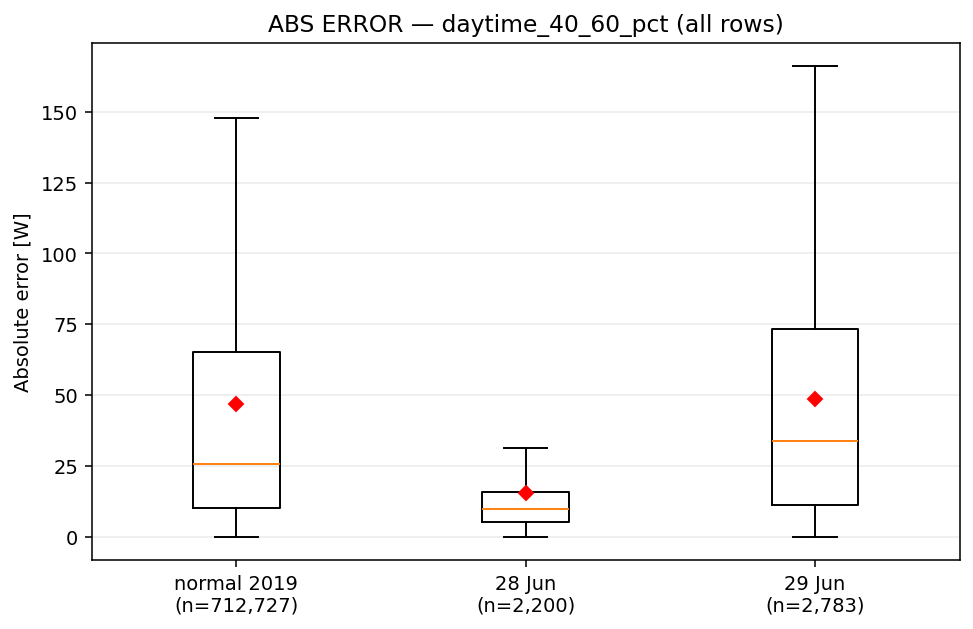

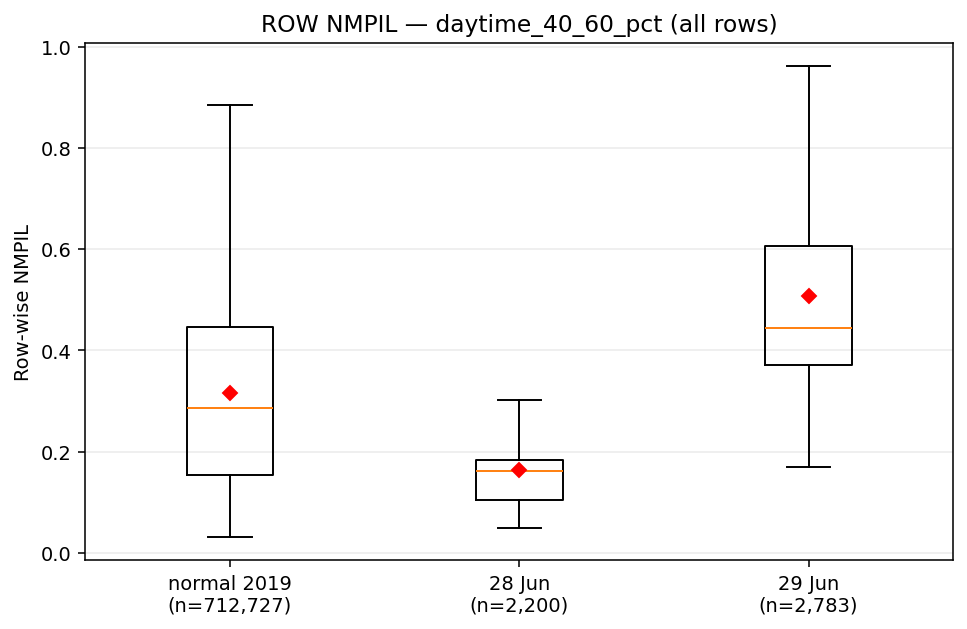

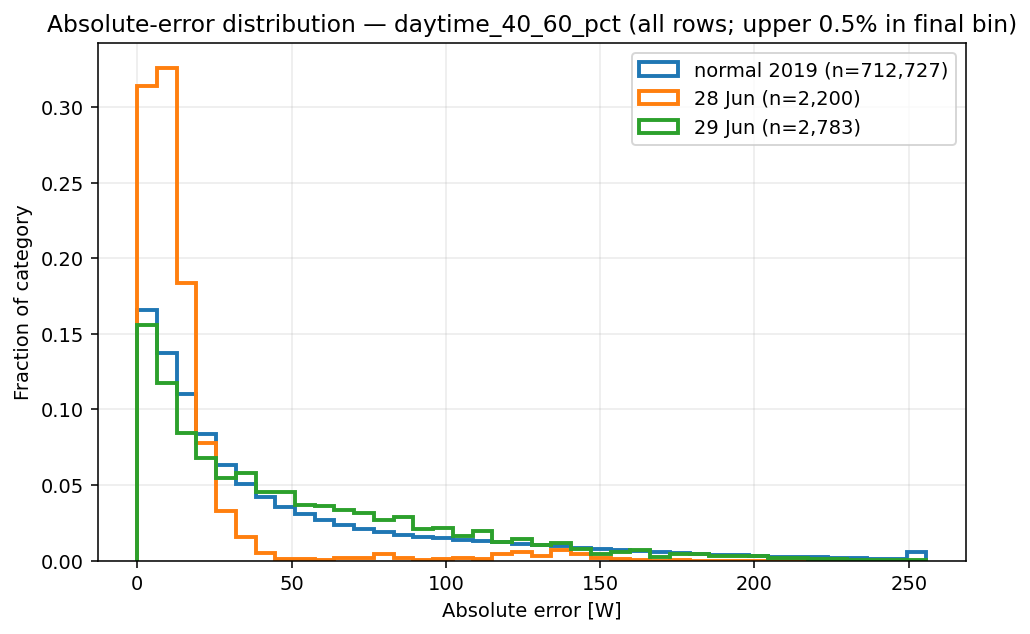

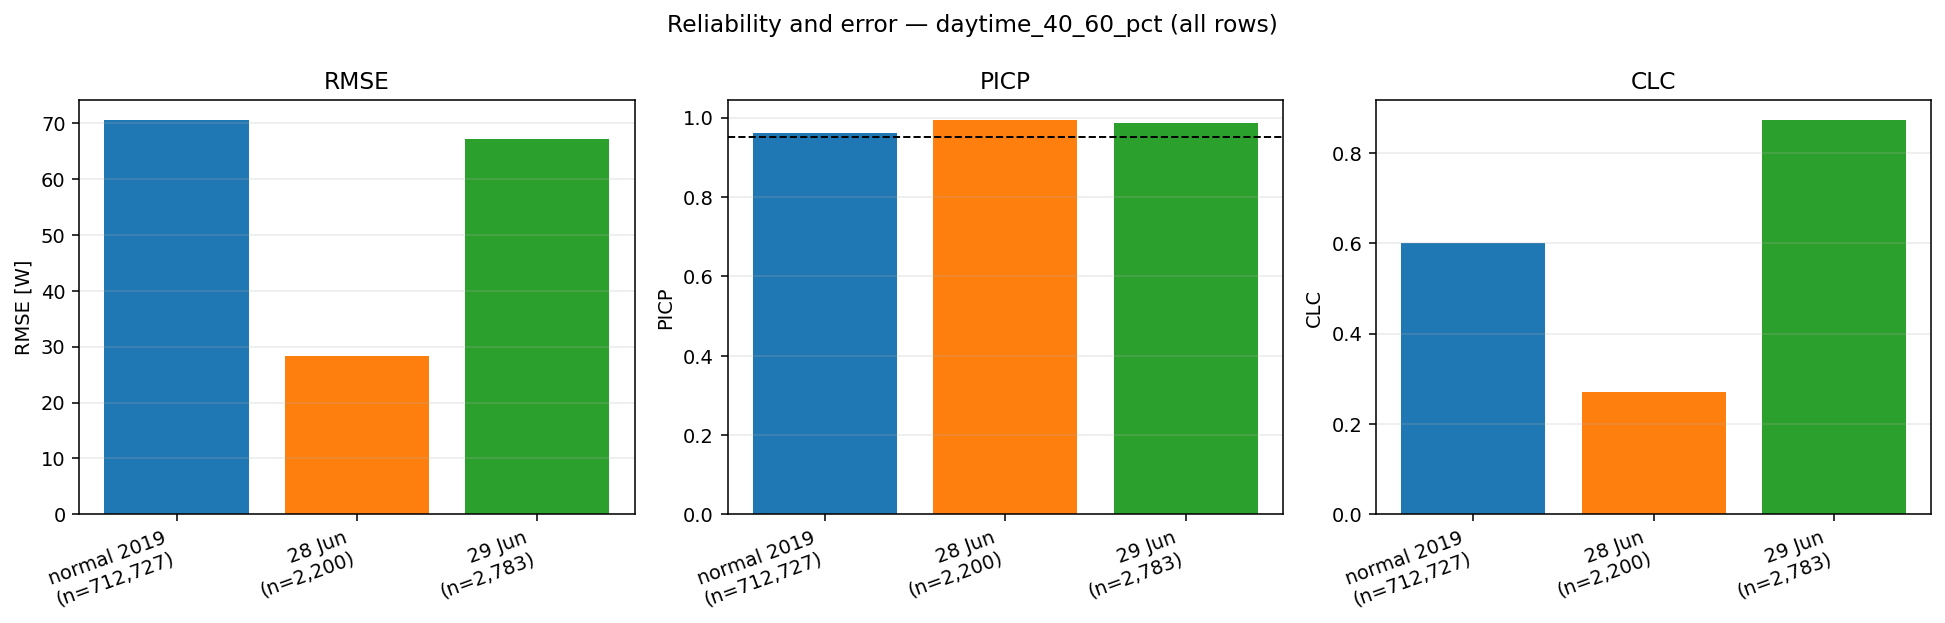

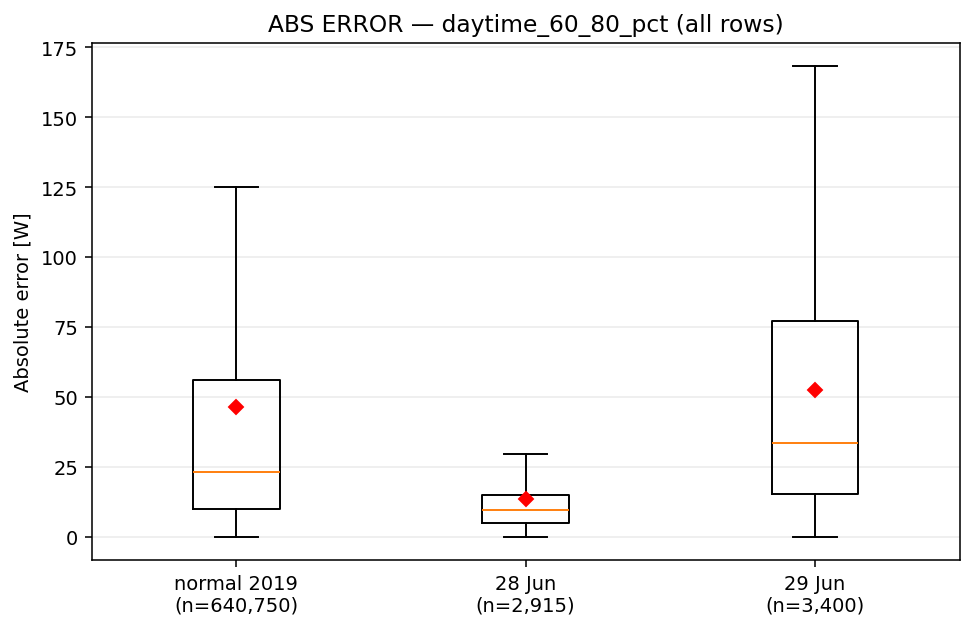

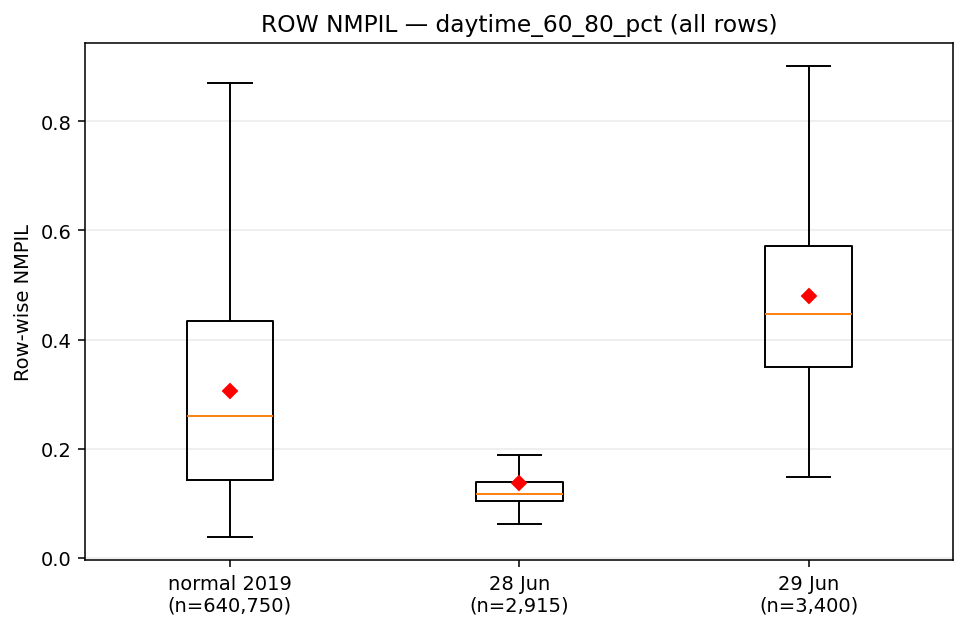

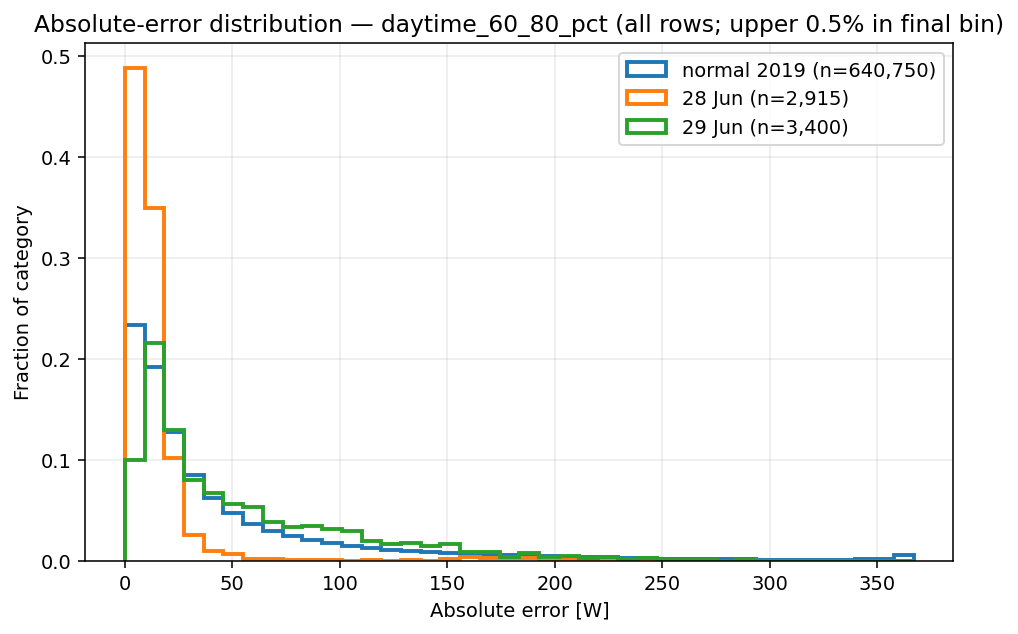

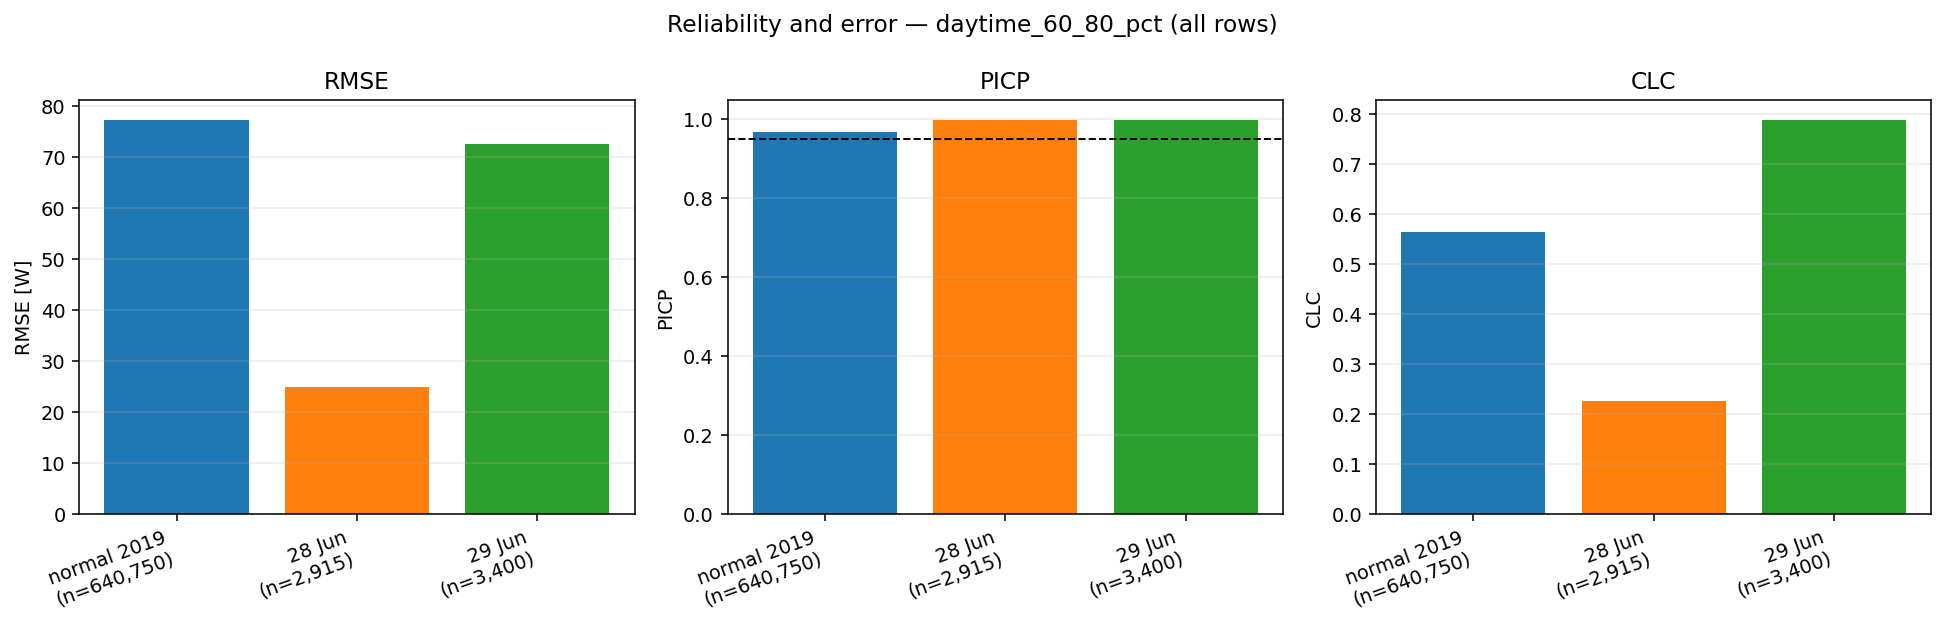

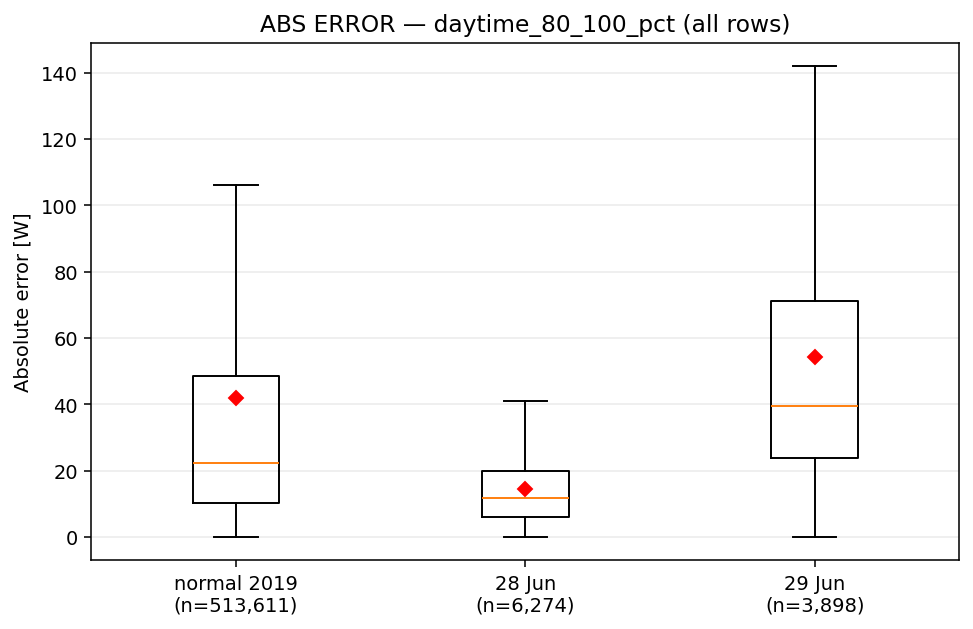

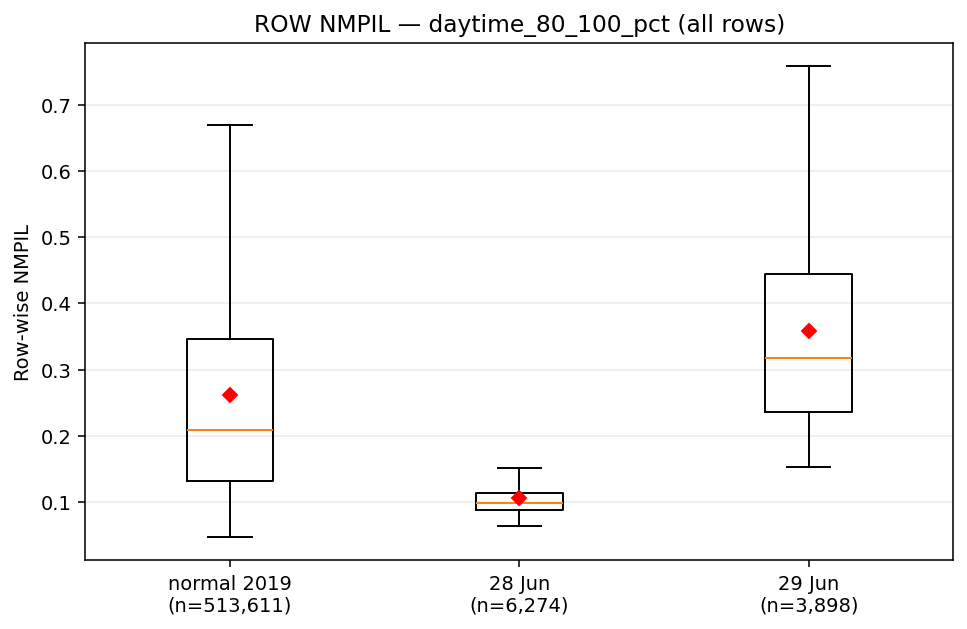

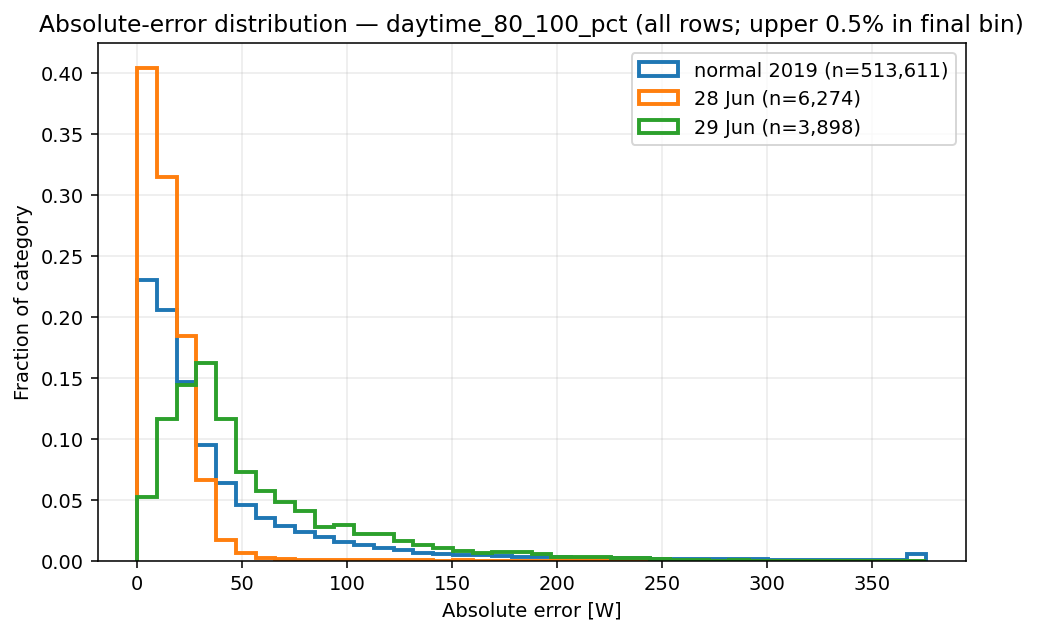

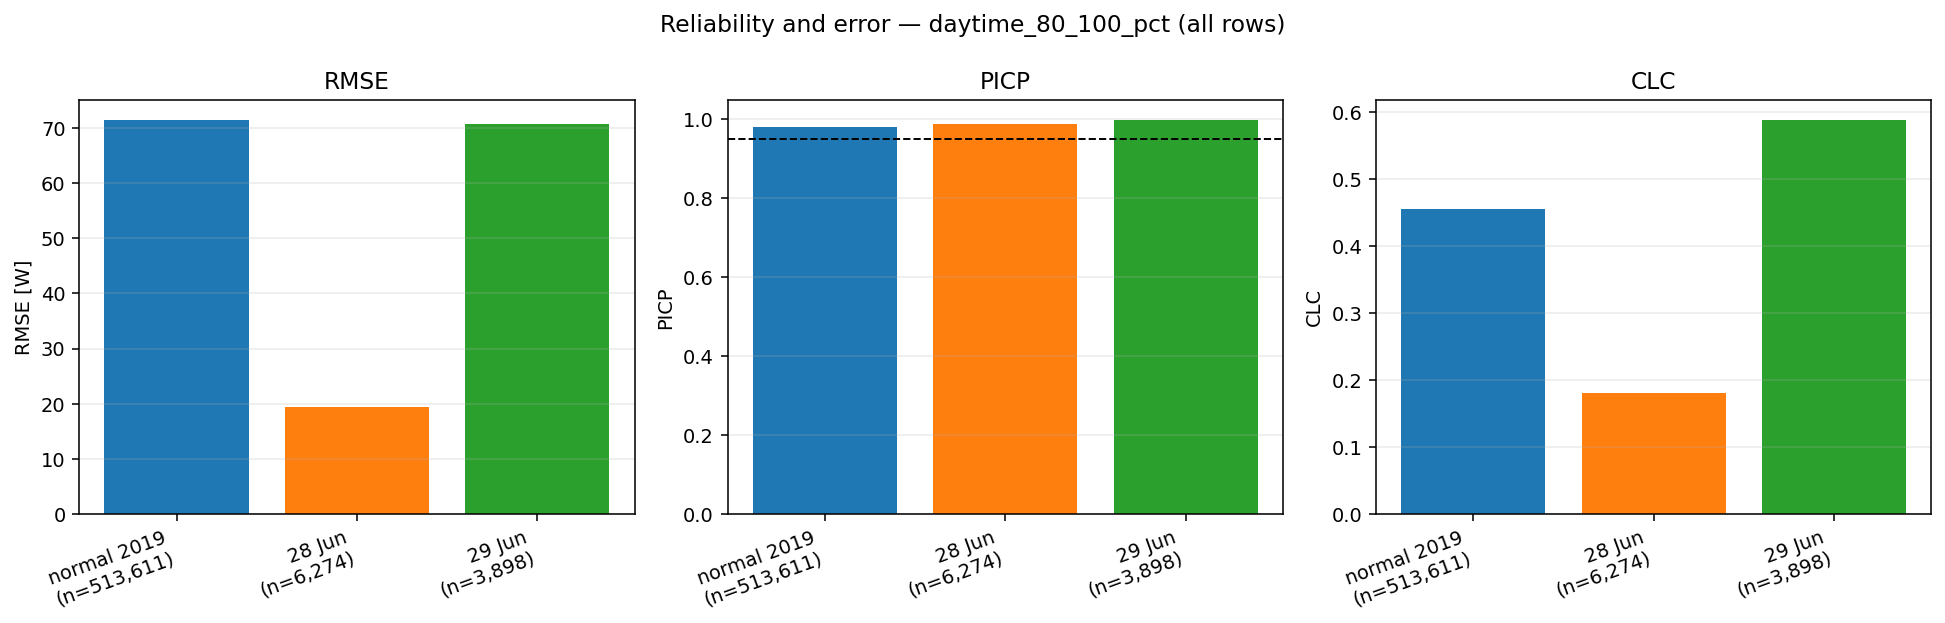

In [3]:
june_comparison = pipe.build_extreme_event_comparison_figures(
    out_dir,
    event_dates=('2019-06-28', '2019-06-29'),
    comparison_name='june_extreme_28_29',
    figure_subdir='june_extreme_event',
)
display(june_comparison['metrics'])
print('CSV metriche:', june_comparison['metrics_path'])
print('Grafici creati:', len(june_comparison['figure_paths']))
for figure_path in june_comparison['figure_paths'].values():
    display(Image(filename=str(figure_path)))